# <font face = 'Impact' color = '#FFAEBC' > Getting Ready with our Second Mini-Project <font/>
#### <font face = 'Times New Roman' color = '#A16AE8'> Author and Trainer: Paolo Hilado MSc. (Data Science)<font/>
In this notebook, we will be importing packages and use them to load and explore data sets. We will be using the pandas package to load datasets and qdesc to explore both categorical and numerical variables. Functions to be used include pd.read_excel, pd.read_csv, head, qd.desc, qd.normcheck_dashboard, qd.freqdist_a, and qd.freqdist_to_excel.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# <font face = 'Impact' color = '#FFAEBC' > Exploring Sleep Hours during Weeknights <font/>

In [ ]:
pip install qdesc

In [ ]:
# Importing the necessary packages for us to use certain functions.
import pandas as pd
import numpy as np
import qdesc as qd

In [ ]:
from types import SimpleNamespace
# Loading a data set (SleepData.xlsx) and storing it into a variable.
df = pd.read_excel('/content/SleepData.xlsx')

In [ ]:
# Check the first 5 rows of the dataframe
df.head()

,Sex,Age,MaritalStatus,Employment,sleep(hrs)/weeknights
0,Male,30,Single,Permanent,8.85
1,Female,58,Married,Permanent,8.76
2,Female,60,Single,Permanent,8.49
3,Male,43,Single,Permanent,8.85
4,Female,43,Single,Permanent,8.73


In [ ]:
# Check the information of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671 entries, 0 to 670
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sex                    671 non-null    object 
 1   Age                    671 non-null    int64  
 2   MaritalStatus          671 non-null    object 
 3   Employment             671 non-null    object 
 4   sleep(hrs)/weeknights  671 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 26.3+ KB


In [ ]:
# Using the desc function from the qdesc package to perform descriptive analysis.
qd.desc(df)


,count,mean,std,median,MAD,min,max,AD_stat,5% crit_value
Age,671.0,49.80,19.36,49.00,17.00,18.00,84.00,7.38,0.78
sleep(hrs)/weeknights,671.0,7.63,1.39,8.34,0.98,4.52,9.88,35.70,0.78


In [ ]:
# Generate descriptive analysis for sleep hours when grouped by sex.
df.groupby('Sex')['sleep(hrs)/weeknights'].describe()


,count,mean,std,min,25%,50%,75%,max
Sex,,,,,,,,
Female,350.0,7.672943,1.358217,4.52,6.3475,8.33,8.88,9.88
Male,321.0,7.574860,1.425584,4.66,6.2100,8.36,8.89,9.64


In [ ]:
# Generate descriptive analysis for sleep hours when grouped by employment.
df.groupby('Employment')['sleep(hrs)/weeknights'].describe()


,count,mean,std,min,25%,50%,75%,max
Employment,,,,,,,,
Permanent,352.0,8.868438,0.322398,7.96,8.64,8.86,9.0925,9.88
Probationary,319.0,6.255078,0.604951,4.52,5.86,6.22,6.6400,7.90


In [ ]:
# Generate descriptive analysis for sleep hours when grouped by marital status.
df.groupby('MaritalStatus')['sleep(hrs)/weeknights'].describe()


,count,mean,std,min,25%,50%,75%,max
MaritalStatus,,,,,,,,
Married,333.0,7.667838,1.396639,4.66,6.2500,8.44,8.93,9.64
Single,338.0,7.584822,1.385605,4.52,6.2725,8.26,8.85,9.88



--- Variable: Age ---
  Anderson-Darling Statistic : 7.3813
  Critical Value (@ 5.0%) : 0.7820
  Decision : Reject Null


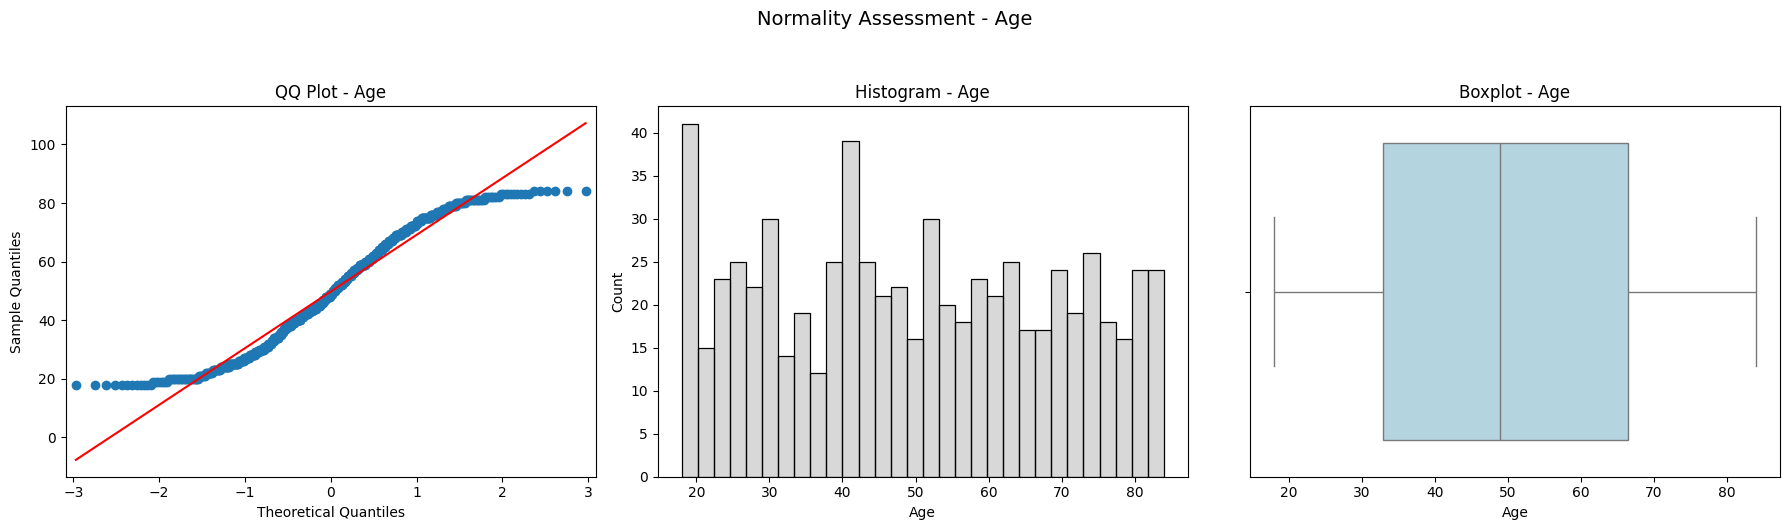


--- Variable: sleep(hrs)/weeknights ---
  Anderson-Darling Statistic : 35.6977
  Critical Value (@ 5.0%) : 0.7820
  Decision : Reject Null


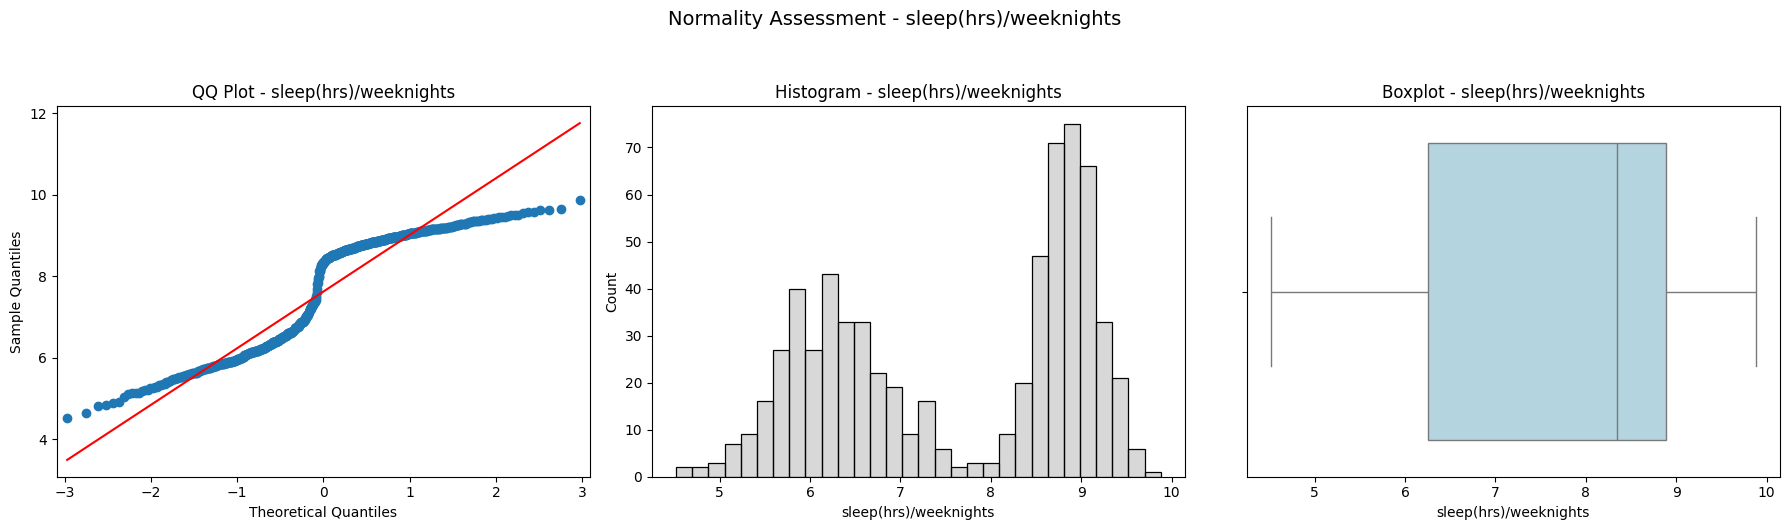

In [ ]:
# Use the desc function from the qdesc package to explore the data for assumption of normality.
qd.normcheck_dashboard(df)

In [ ]:
# Slicing the data frame to only include the single.
single_df = df[df['MaritalStatus'] == 'Single'].copy()
single_df

,Sex,Age,MaritalStatus,Employment,sleep(hrs)/weeknights
0,Male,30,Single,Permanent,8.85
2,Female,60,Single,Permanent,8.49
3,Male,43,Single,Permanent,8.85
4,Female,43,Single,Permanent,8.73
6,Male,45,Single,Permanent,8.36
...,...,...,...,...,...
663,Female,61,Single,Probationary,6.51
664,Male,39,Single,Probationary,5.74
667,Female,76,Single,Probationary,4.90
669,Female,25,Single,Probationary,5.18


In [ ]:
# Confirm that the subset would only include those who are single.
print(single_df['MaritalStatus'].unique())

['Single']


In [ ]:
# Use the qdesc package to explore the data (only those who are Single) for assumption of normality.
qd.desc(single_df)

,count,mean,std,median,MAD,min,max,AD_stat,5% crit_value
Age,338.0,50.74,19.11,50.00,16.00,18.00,84.00,3.05,0.78
sleep(hrs)/weeknights,338.0,7.58,1.39,8.26,1.01,4.52,9.88,16.56,0.78


In [ ]:
# Slicing the data frame to only include the married.
married_df = df[df['MaritalStatus'] == 'Married'].copy()
married_df

,Sex,Age,MaritalStatus,Employment,sleep(hrs)/weeknights
1,Female,58,Married,Permanent,8.76
5,Female,32,Married,Permanent,8.70
10,Female,29,Married,Permanent,9.05
11,Female,31,Married,Permanent,9.41
12,Male,38,Married,Permanent,8.94
...,...,...,...,...,...
661,Female,67,Married,Probationary,7.20
662,Male,20,Married,Probationary,6.38
665,Male,39,Married,Probationary,6.22
666,Female,59,Married,Probationary,6.15


In [ ]:
# Confirm that the subset is all married.
print(married_df['MaritalStatus'].unique())

['Married']



--- Variable: Age ---
  Anderson-Darling Statistic : 4.7098
  Critical Value (@ 5.0%) : 0.7780
  Decision : Reject Null


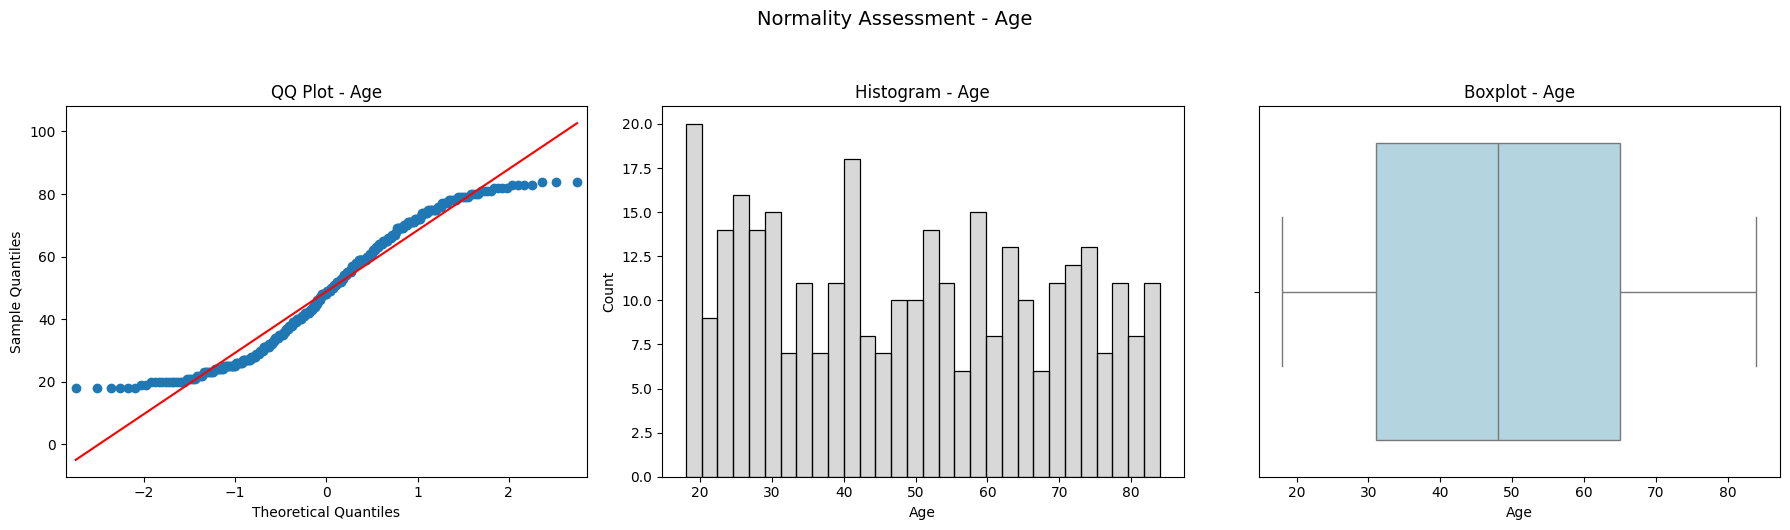


--- Variable: sleep(hrs)/weeknights ---
  Anderson-Darling Statistic : 19.3198
  Critical Value (@ 5.0%) : 0.7780
  Decision : Reject Null


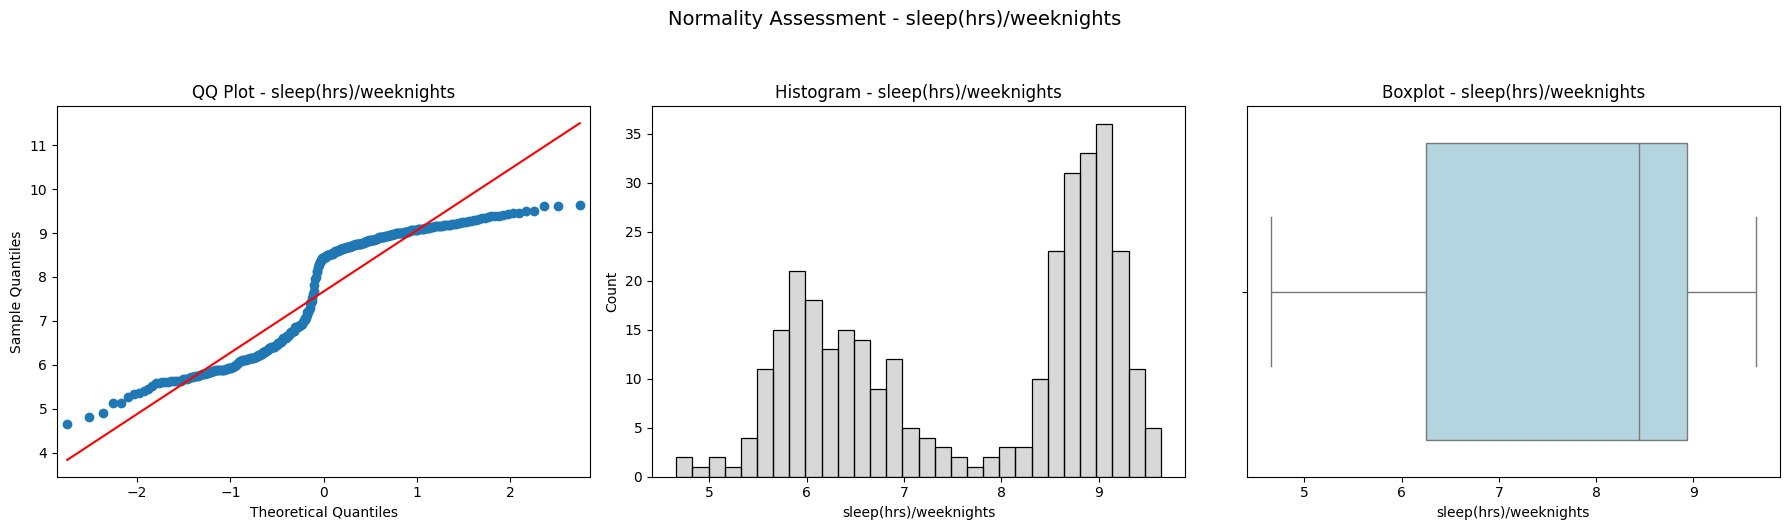

In [ ]:
# Use the qdesc package to explore the data for assumption of normality.
qd.normcheck_dashboard(married_df)

In [ ]:
# Generate a frequency distribution for a specified variable: Sex
df ["Sex"].value_counts()

,count
Sex,
Female,350
Male,321


In [ ]:
# Generate a frequency distribution for a specified variable: Employment
df ["Employment"].value_counts()


,count
Employment,
Permanent,352
Probationary,319


In [ ]:
# Generate a frequency distribution for a specified variable: Marital Status
df ["MaritalStatus"].value_counts()


,count
MaritalStatus,
Single,338
Married,333


In [ ]:
# Generate frequency distribution for all the categorical features from the said data frame.
categorical_cols = ['Sex', 'Employment', 'MaritalStatus']
for col in categorical_cols:
    print(f"Frequency distribution for {col}:")
    print(df[col].value_counts())
    print("\n")

Frequency distribution for Sex:
Sex
Female    350
Male      321
Name: count, dtype: int64


Frequency distribution for Employment:
Employment
Permanent       352
Probationary    319
Name: count, dtype: int64


Frequency distribution for MaritalStatus:
MaritalStatus
Single     338
Married    333
Name: count, dtype: int64




In [ ]:
# Generating a frequency distribution but this time have it stored in an excel file and organized
# on a per sheet basis per categorical feature.

categorical_cols = ['Sex', 'Employment', 'MaritalStatus']
output_filename = 'frequency_distributions.xlsx'

with pd.ExcelWriter(output_filename) as writer:
    for col in categorical_cols:
        freq_dist = df[col].value_counts()
        freq_dist.to_excel(writer, sheet_name=col)

print(f"Frequency distributions saved to {output_filename}")

Frequency distributions saved to frequency_distributions.xlsx


In [ ]:
# @title Analysis

#The dataset contains information on sleep hours during weeknights, along with demographic and employment details for 671 individuals.
Descriptive Analysis:
The average age of the participants is approximately 49.8 years, with a standard deviation of 19.36 years, indicating a wide range of ages in the sample. The median age is 49.0 years.
The average sleep duration during weeknights is about 7.63 hours, with a standard deviation of 1.39 hours. The sleep duration ranges from 4.52 to 9.88 hours, with a median of 8.34 hours.

Descriptive Analysis by Group:
Sex: Females have a slightly higher average sleep duration (7.67 hours) compared to males (7.57 hours). The standard deviations are similar for both groups.
Employment: Individuals with Permanent employment have a significantly higher average sleep duration (8.87 hours) compared to those with Probationary employment (6.26 hours). The standard deviation is much lower for the Permanent group, suggesting less variability in sleep hours within this group.
Marital Status: There is a small difference in average sleep duration between Married (7.67 hours) and Single individuals (7.58 hours).

Normality Check:
The Anderson-Darling test and visual inspection of the QQ plots, histograms, and boxplots indicate that neither 'Age' nor 'sleep(hrs)/weeknights' are normally distributed. The histograms for 'sleep(hrs)/weeknights' show a bimodal distribution, suggesting there might be distinct subgroups with different sleep patterns.

Frequency Distributions:
The dataset includes a roughly equal number of Female (350) and Male (321) participants.
There are slightly more individuals with Permanent employment (352) than Probationary employment (319).
The distribution of Marital Status is also quite balanced, with 338 Single individuals and 333 Married individuals.
Overall, the analysis reveals variations in sleep hours based on employment status, with permanent employees reporting significantly more sleep. There are also slight differences in sleep duration based on sex and marital status. The normality assumption is not met for age and sleep hours, which is important to consider for further statistical analysis.